# Milestone 3 - Modelação e Avaliação (Objetivo 3)

Neste notebook é realizada uma análise de clustering com o objetivo de identificar e caracterizar perfis distintos de colaboradores com base nas variáveis relevantes do dataset IBM HR Analytics Employee Attrition & Performance.

Esta etapa enquadra-se nas fases de Modelling e Evaluation da metodologia CRISP-DM, complementando a modelação supervisionada desenvolvida nos objetivos anteriores, ao permitir uma análise exploratória avançada da estrutura dos dados.

O objetivo principal deste notebook consiste em aplicar técnicas de clustering para segmentar os colaboradores em grupos homogéneos, determinando o número ótimo de clusters com base no método do cotovelo (Elbow Method) e na métrica de Silhouette Score, garantindo um valor médio de Silhouette superior a 0,50.

Importa salientar que, ao contrário dos modelos supervisionados, esta abordagem não utiliza a variável alvo (Attrition), focando-se exclusivamente na identificação de padrões e estruturas latentes nos dados.

Após a preparação dos dados para clustering, esta fase tem como propósito:

- Selecionar e preparar as variáveis relevantes para a análise de agrupamento;
- Aplicar diversos algoritmos de clustering para segmentação dos colaboradores;
- Determinar o número ótimo de clusters através do método do cotovelo (Elbow Method);
- Avaliar a qualidade dos agrupamentos através do Silhouette Score, garantindo um nível adequado de coesão e separação entre clusters;
- Analisar a distribuição dos colaboradores pelos diferentes grupos identificados;
- Caracterizar estatisticamente cada cluster, com base nas variáveis mais relevantes;
- Interpretar os perfis obtidos, identificando padrões distintos de comportamento organizacional;
- Relacionar, de forma exploratória, os clusters com a variável Attrition, de modo a avaliar se existem perfis com maior propensão ao abandono.

A análise de clustering permite identificar segmentos de colaboradores com características semelhantes, proporcionando uma visão complementar à modelação supervisionada. Esta abordagem pode apoiar a definição de estratégias diferenciadas de gestão de recursos humanos, adaptadas aos diferentes perfis identificados.

**Autores: Luís Figueira, Martim Ferreira e Mateus Afonso (Figueira,L., Afonso, M. e Ferreira, M.)**

## 1. Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score
)

import warnings
warnings.filterwarnings('ignore')
print('Bibliotecas importadas com sucesso.')

Bibliotecas importadas com sucesso.


## 2. Carregamento dos Datasets

In [2]:
# Dataset de clustering (sem variável alvo)
base_cluster = 'https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/Objetivo3/treino'
X = pd.read_csv(f'{base_cluster}/X.csv')

# Dataset completo — usado apenas para estratificação do split
url_full = 'https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv'
df_full  = pd.read_csv(url_full)

print(f'Dataset clustering: {X.shape[0]} linhas, {X.shape[1]} colunas')
print(f'Dataset completo:   {df_full.shape[0]} linhas, {df_full.shape[1]} colunas')

Dataset clustering: 1470 linhas, 53 colunas
Dataset completo:   1470 linhas, 62 colunas


## 3. Divisão Treino / Teste (80/20, estratificado por Attrition_bin)

> O `StandardScaler` faz `fit` apenas no treino para evitar *data leakage*.

In [3]:
attrition_strat = df_full['Attrition_bin'].values

X_train, X_test, _, _ = train_test_split(
    X, attrition_strat,
    test_size=0.2,
    random_state=42,
    stratify=attrition_strat
)

print('Divisao treino/teste (80/20, estratificada por Attrition_bin):')
print(f'  Treino: {X_train.shape[0]} amostras  ({X_train.shape[0]/X.shape[0]*100:.0f}%)')
print(f'  Teste:  {X_test.shape[0]} amostras  ({X_test.shape[0]/X.shape[0]*100:.0f}%)')
print(f'\n  Proporcao Attrition no treino: {df_full["Attrition_bin"].iloc[X_train.index].mean()*100:.1f}%')
print(f'  Proporcao Attrition no teste:  {df_full["Attrition_bin"].iloc[X_test.index].mean()*100:.1f}%')

Divisao treino/teste (80/20, estratificada por Attrition_bin):
  Treino: 1176 amostras  (80%)
  Teste:  294 amostras  (20%)

  Proporcao Attrition no treino: 16.2%
  Proporcao Attrition no teste:  16.0%


## 4. Normalização

O `StandardScaler` é ajustado (`.fit_transform`) apenas no treino. No teste aplica-se apenas `.transform` com os parâmetros já aprendidos — sem *data leakage*.

In [4]:
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('StandardScaler aplicado (fit no treino, transform no teste).')
print(f'  Media treino:  {X_train_scaled.mean():.4f}  (deve ser ~0)')
print(f'  Std   treino:  {X_train_scaled.std():.4f}  (deve ser ~1)')

StandardScaler aplicado (fit no treino, transform no teste).
  Media treino:  0.0000  (deve ser ~0)
  Std   treino:  1.0000  (deve ser ~1)


## 5. Baseline — K-Means k=5

Recalculado com o **mesmo split 80/20 estratificado** para ser diretamente comparável com os candidatos.

> Parâmetros totalmente default — sem `random_state` nem `n_init`.

In [5]:
kmeans_base         = KMeans(n_clusters=5)
clusters_train_base = kmeans_base.fit_predict(X_train_scaled)
clusters_test_base  = kmeans_base.predict(X_test_scaled)

sil_train_base = silhouette_score(X_train_scaled, clusters_train_base)
db_train_base  = davies_bouldin_score(X_train_scaled, clusters_train_base)
ch_train_base  = calinski_harabasz_score(X_train_scaled, clusters_train_base)

sil_test_base  = silhouette_score(X_test_scaled, clusters_test_base)
db_test_base   = davies_bouldin_score(X_test_scaled, clusters_test_base)
ch_test_base   = calinski_harabasz_score(X_test_scaled, clusters_test_base)

print('===== BASELINE — K-Means k=5 =====')
print(f'{"Metrica":<25} {"Treino":>10} {"Teste":>10}')
print(f'{"-"*45}')
print(f'{"Silhouette Score":<25} {sil_train_base:>10.4f} {sil_test_base:>10.4f}')
print(f'{"Davies-Bouldin":<25} {db_train_base:>10.4f} {db_test_base:>10.4f}')
print(f'{"Calinski-Harabasz":<25} {ch_train_base:>10.2f} {ch_test_base:>10.2f}')
print(f'\n  Meta Silhouette > 0.50: {"ATINGIDA" if sil_test_base > 0.50 else "NAO ATINGIDA"}')
print(f'\nDistribuicao clusters — Treino:')
print(pd.Series(clusters_train_base).value_counts().sort_index().to_string())
print(f'\nDistribuicao clusters — Teste:')
print(pd.Series(clusters_test_base).value_counts().sort_index().to_string())

===== BASELINE — K-Means k=5 =====
Metrica                       Treino      Teste
---------------------------------------------
Silhouette Score              0.0453     0.0394
Davies-Bouldin                3.3970     3.2775
Calinski-Harabasz              60.34      16.37

  Meta Silhouette > 0.50: NAO ATINGIDA

Distribuicao clusters — Treino:
0    138
1    196
2    340
3    107
4    395

Distribuicao clusters — Teste:
0    32
1    58
2    81
3    24
4    99


### 5.1 Silhouette Plot — Baseline (Treino)

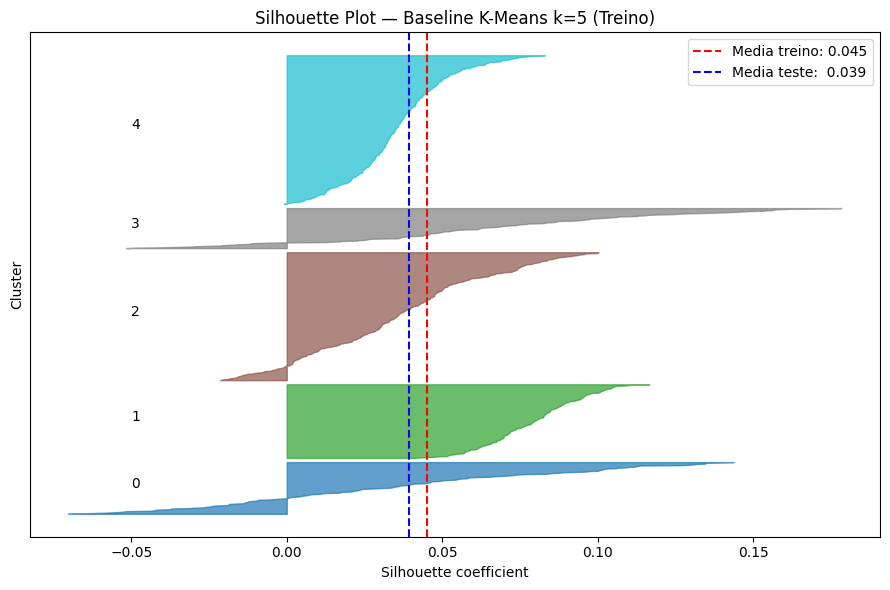

In [6]:
sample_sil_base = silhouette_samples(X_train_scaled, clusters_train_base)

fig, ax = plt.subplots(figsize=(9, 6))
y_lower   = 10
colors_b  = plt.cm.tab10(np.linspace(0, 1, 5))

for i in range(5):
    vals    = sample_sil_base[clusters_train_base == i]
    vals.sort()
    size    = vals.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     facecolor=colors_b[i], edgecolor=colors_b[i], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=10)
    y_lower = y_upper + 10

ax.axvline(sil_train_base, color='red',  linestyle='--', linewidth=1.5, label=f'Media treino: {sil_train_base:.3f}')
ax.axvline(sil_test_base,  color='blue', linestyle='--', linewidth=1.5, label=f'Media teste:  {sil_test_base:.3f}')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_title('Silhouette Plot — Baseline K-Means k=5 (Treino)')
ax.set_yticks([])
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('silhouette_plot_baseline_split.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Visualização PCA — Baseline Treino vs. Teste

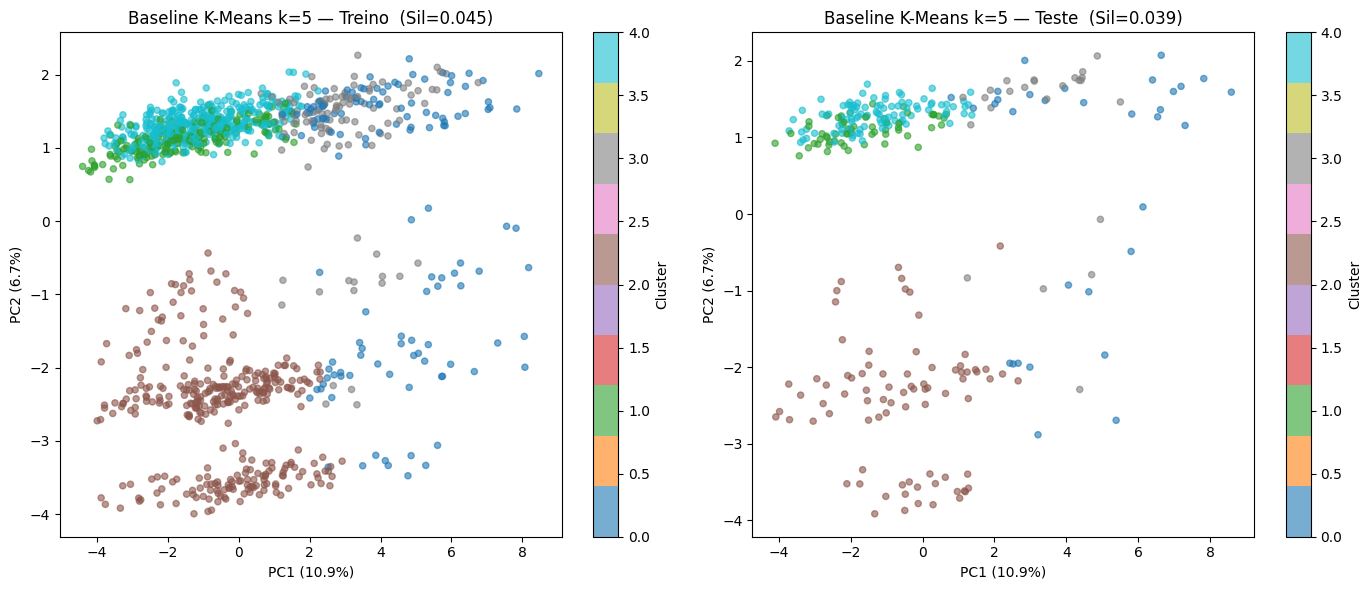

In [7]:
pca_base         = PCA(n_components=2, random_state=42)
X_train_pca_base = pca_base.fit_transform(X_train_scaled)
X_test_pca_base  = pca_base.transform(X_test_scaled)
var_base         = pca_base.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc1 = axes[0].scatter(X_train_pca_base[:, 0], X_train_pca_base[:, 1],
                      c=clusters_train_base, cmap='tab10', alpha=0.6, s=20)
axes[0].set_title(f'Baseline K-Means k=5 — Treino  (Sil={sil_train_base:.3f})')
axes[0].set_xlabel(f'PC1 ({var_base[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({var_base[1]*100:.1f}%)')
plt.colorbar(sc1, ax=axes[0], label='Cluster')

sc2 = axes[1].scatter(X_test_pca_base[:, 0], X_test_pca_base[:, 1],
                      c=clusters_test_base, cmap='tab10', alpha=0.6, s=20)
axes[1].set_title(f'Baseline K-Means k=5 — Teste  (Sil={sil_test_base:.3f})')
axes[1].set_xlabel(f'PC1 ({var_base[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({var_base[1]*100:.1f}%)')
plt.colorbar(sc2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.savefig('pca_baseline_treino_teste.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Distribuição dos Clusters — Baseline Treino vs. Teste

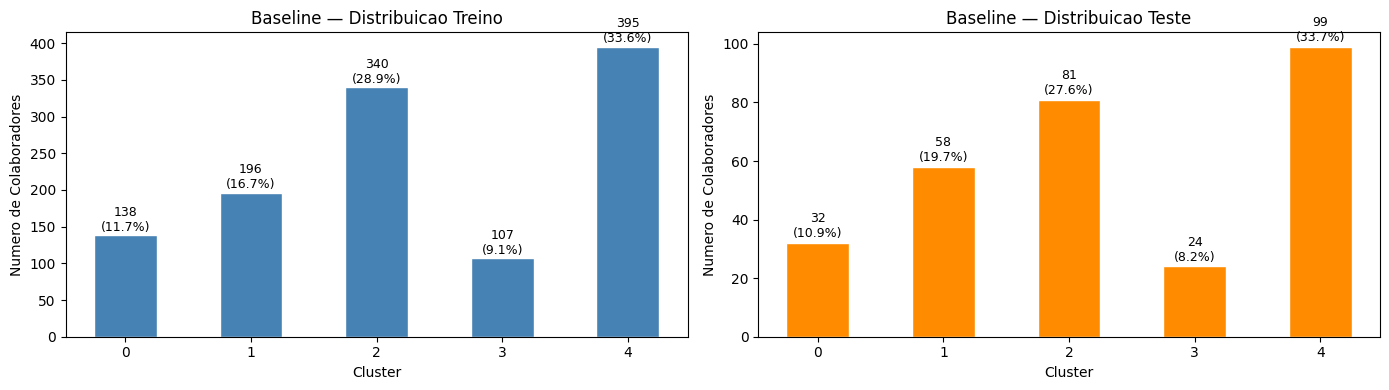

In [8]:
contagem_base_train = pd.Series(clusters_train_base).value_counts().sort_index()
contagem_base_test  = pd.Series(clusters_test_base).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

bars1 = axes[0].bar(contagem_base_train.index, contagem_base_train.values,
                    color='steelblue', edgecolor='white', width=0.5)
for bar, val in zip(bars1, contagem_base_train.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{val}\n({val/len(clusters_train_base)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9)
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Numero de Colaboradores')
axes[0].set_title('Baseline — Distribuicao Treino')
axes[0].set_xticks(contagem_base_train.index)

bars2 = axes[1].bar(contagem_base_test.index, contagem_base_test.values,
                    color='darkorange', edgecolor='white', width=0.5)
for bar, val in zip(bars2, contagem_base_test.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val}\n({val/len(clusters_test_base)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Numero de Colaboradores')
axes[1].set_title('Baseline — Distribuicao Teste')
axes[1].set_xticks(contagem_base_test.index)

plt.tight_layout()
plt.savefig('distribuicao_baseline_treino_teste.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Candidato 1 — K-Means Otimizado

Pesquisa do k ótimo por Silhouette Score no conjunto de treino, seguida de treino do modelo final e avaliação no teste.


### 6.1 Pesquisa do k ótimo — Elbow + Silhouette (Treino)

In [9]:
K_RANGE      = range(2, 11)
resultados_k = []

for k in K_RANGE:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train_scaled)
    resultados_k.append({
        'k':                 k,
        'Inercia':           km.inertia_,
        'Silhouette':        silhouette_score(X_train_scaled, labels),
        'Davies-Bouldin':    davies_bouldin_score(X_train_scaled, labels),
        'Calinski-Harabasz': calinski_harabasz_score(X_train_scaled, labels),
    })

df_k     = pd.DataFrame(resultados_k).round(4)
melhor_k = int(df_k.loc[df_k['Silhouette'].idxmax(), 'k'])

print('Tabela de metricas por k (treino):')
display(df_k)
print(f'\nMelhor k por Silhouette: {melhor_k}  '
      f'({df_k.loc[df_k["k"]==melhor_k, "Silhouette"].values[0]:.4f})')

Tabela de metricas por k (treino):


,k,Inercia,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,57689.9738,0.1056,3.1380,94.3846
1,3,54213.0982,0.0769,2.9598,87.7904
2,4,51365.3072,0.0895,2.5451,83.3784
3,5,49770.9766,0.0827,2.9037,73.8597
4,6,48644.8737,0.0713,2.9515,65.8209
5,7,47096.0356,0.0816,2.7996,63.0137
6,8,45658.9897,0.1017,2.4666,60.9156
7,9,44627.2094,0.0982,2.4614,57.8594
8,10,43101.7836,0.1092,2.4058,57.7903



Melhor k por Silhouette: 10  (0.1092)


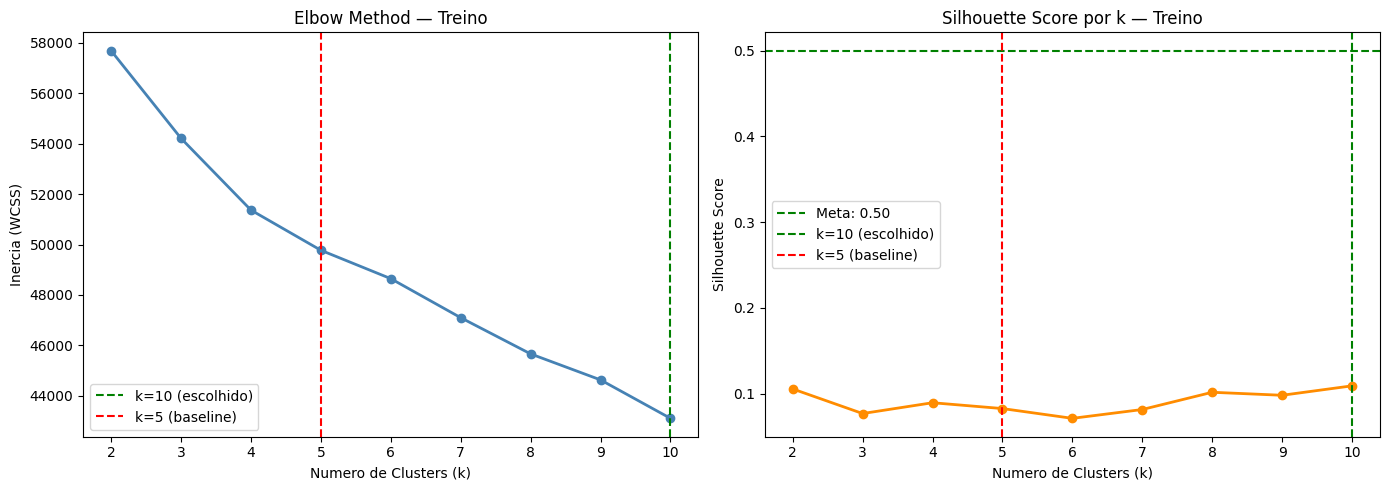

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_k['k'], df_k['Inercia'], marker='o', color='steelblue', linewidth=2)
axes[0].axvline(melhor_k, color='green', linestyle='--', linewidth=1.5, label=f'k={melhor_k} (escolhido)')
axes[0].axvline(5, color='red', linestyle='--', linewidth=1.5, label='k=5 (baseline)')
axes[0].set_xlabel('Numero de Clusters (k)')
axes[0].set_ylabel('Inercia (WCSS)')
axes[0].set_title('Elbow Method — Treino')
axes[0].set_xticks(list(K_RANGE))
axes[0].legend()

axes[1].plot(df_k['k'], df_k['Silhouette'], marker='o', color='darkorange', linewidth=2)
axes[1].axhline(0.50, color='green', linestyle='--', linewidth=1.5, label='Meta: 0.50')
axes[1].axvline(melhor_k, color='green', linestyle='--', linewidth=1.5, label=f'k={melhor_k} (escolhido)')
axes[1].axvline(5, color='red', linestyle='--', linewidth=1.5, label='k=5 (baseline)')
axes[1].set_xlabel('Numero de Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por k — Treino')
axes[1].set_xticks(list(K_RANGE))
axes[1].legend()

plt.tight_layout()
plt.savefig('kmeans_pesquisa_k.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Treino do Modelo Final e Métricas Treino vs. Teste

In [11]:
kmeans_final      = KMeans(n_clusters=melhor_k, random_state=42, n_init=10)
clusters_train_km = kmeans_final.fit_predict(X_train_scaled)
clusters_test_km  = kmeans_final.predict(X_test_scaled)

sil_train_km = silhouette_score(X_train_scaled, clusters_train_km)
db_train_km  = davies_bouldin_score(X_train_scaled, clusters_train_km)
ch_train_km  = calinski_harabasz_score(X_train_scaled, clusters_train_km)

sil_test_km  = silhouette_score(X_test_scaled, clusters_test_km)
db_test_km   = davies_bouldin_score(X_test_scaled, clusters_test_km)
ch_test_km   = calinski_harabasz_score(X_test_scaled, clusters_test_km)

print(f'===== K-MEANS k={melhor_k} — TREINO vs. TESTE =====')
print(f'{"Metrica":<25} {"Treino":>10} {"Teste":>10} {"Diferenca":>12}')
print(f'{"-"*57}')
print(f'{"Silhouette Score":<25} {sil_train_km:>10.4f} {sil_test_km:>10.4f} {abs(sil_train_km-sil_test_km):>12.4f}')
print(f'{"Davies-Bouldin":<25} {db_train_km:>10.4f} {db_test_km:>10.4f} {abs(db_train_km-db_test_km):>12.4f}')
print(f'{"Calinski-Harabasz":<25} {ch_train_km:>10.2f} {ch_test_km:>10.2f} {abs(ch_train_km-ch_test_km):>12.2f}')
print(f'\n  Meta Silhouette > 0.50 (Treino): {"ATINGIDA" if sil_train_km > 0.50 else "NAO ATINGIDA"}')
print(f'  Meta Silhouette > 0.50 (Teste):  {"ATINGIDA" if sil_test_km  > 0.50 else "NAO ATINGIDA"}')
print(f'\nDistribuicao clusters — Treino:')
print(pd.Series(clusters_train_km).value_counts().sort_index().to_string())
print(f'\nDistribuicao clusters — Teste:')
print(pd.Series(clusters_test_km).value_counts().sort_index().to_string())

===== K-MEANS k=10 — TREINO vs. TESTE =====
Metrica                       Treino      Teste    Diferenca
---------------------------------------------------------
Silhouette Score              0.1092     0.1101       0.0009
Davies-Bouldin                2.4058     2.2730       0.1327
Calinski-Harabasz              57.79      16.10        41.69

  Meta Silhouette > 0.50 (Treino): NAO ATINGIDA
  Meta Silhouette > 0.50 (Teste):  NAO ATINGIDA

Distribuicao clusters — Treino:
0     89
1    223
2    209
3     94
4     60
5    108
6     84
7    205
8     41
9     63

Distribuicao clusters — Teste:
0    17
1    45
2    69
3    20
4    23
5    32
6    19
7    41
8    11
9    17


### 6.3 Silhouette Plot — K-Means Otimizado (Treino)

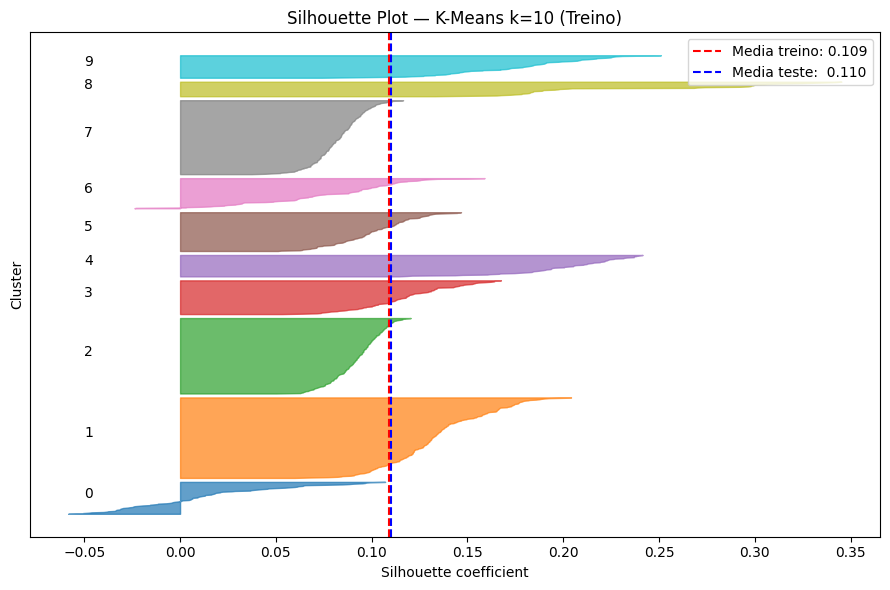

In [12]:
sample_sil_km = silhouette_samples(X_train_scaled, clusters_train_km)

fig, ax = plt.subplots(figsize=(9, 6))
y_lower  = 10
colors   = plt.cm.tab10(np.linspace(0, 1, melhor_k))

for i in range(melhor_k):
    vals    = sample_sil_km[clusters_train_km == i]
    vals.sort()
    size    = vals.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     facecolor=colors[i], edgecolor=colors[i], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=10)
    y_lower = y_upper + 10

ax.axvline(sil_train_km, color='red',  linestyle='--', linewidth=1.5, label=f'Media treino: {sil_train_km:.3f}')
ax.axvline(sil_test_km,  color='blue', linestyle='--', linewidth=1.5, label=f'Media teste:  {sil_test_km:.3f}')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_title(f'Silhouette Plot — K-Means k={melhor_k} (Treino)')
ax.set_yticks([])
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('silhouette_plot_kmeans_otimizado.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.4 Visualização PCA — K-Means Treino vs. Teste

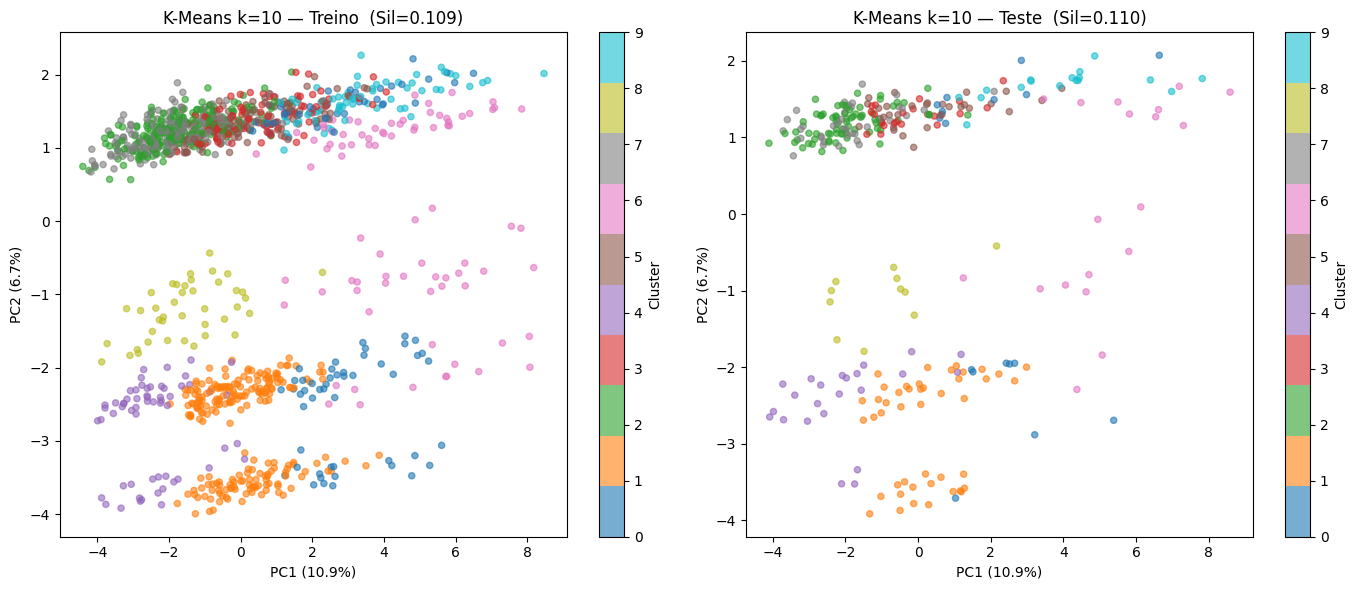

In [13]:
pca         = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)
variancia   = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc1 = axes[0].scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                      c=clusters_train_km, cmap='tab10', alpha=0.6, s=20)
axes[0].set_title(f'K-Means k={melhor_k} — Treino  (Sil={sil_train_km:.3f})')
axes[0].set_xlabel(f'PC1 ({variancia[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({variancia[1]*100:.1f}%)')
plt.colorbar(sc1, ax=axes[0], label='Cluster')

sc2 = axes[1].scatter(X_test_pca[:, 0], X_test_pca[:, 1],
                      c=clusters_test_km, cmap='tab10', alpha=0.6, s=20)
axes[1].set_title(f'K-Means k={melhor_k} — Teste  (Sil={sil_test_km:.3f})')
axes[1].set_xlabel(f'PC1 ({variancia[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({variancia[1]*100:.1f}%)')
plt.colorbar(sc2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.savefig('pca_kmeans_treino_teste.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.5 Distribuição dos Clusters — K-Means Treino vs. Teste

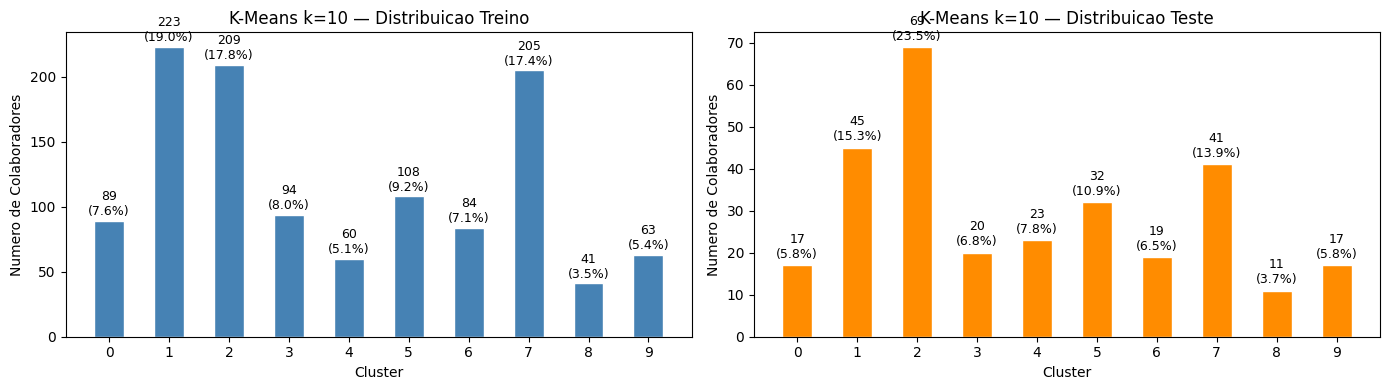

In [14]:
contagem_km_train = pd.Series(clusters_train_km).value_counts().sort_index()
contagem_km_test  = pd.Series(clusters_test_km).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

bars1 = axes[0].bar(contagem_km_train.index, contagem_km_train.values,
                    color='steelblue', edgecolor='white', width=0.5)
for bar, val in zip(bars1, contagem_km_train.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{val}\n({val/len(clusters_train_km)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9)
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Numero de Colaboradores')
axes[0].set_title(f'K-Means k={melhor_k} — Distribuicao Treino')
axes[0].set_xticks(contagem_km_train.index)

bars2 = axes[1].bar(contagem_km_test.index, contagem_km_test.values,
                    color='darkorange', edgecolor='white', width=0.5)
for bar, val in zip(bars2, contagem_km_test.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val}\n({val/len(clusters_test_km)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Numero de Colaboradores')
axes[1].set_title(f'K-Means k={melhor_k} — Distribuicao Teste')
axes[1].set_xticks(contagem_km_test.index)

plt.tight_layout()
plt.savefig('distribuicao_kmeans_treino_teste.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Candidato 2 — DBSCAN

Algoritmo baseado em densidade que não requer definir k à priori. Identifica automaticamente o número de clusters e marca pontos isolados como ruído.

### 7.1 K-distance Plot — Escolha do eps (Treino)

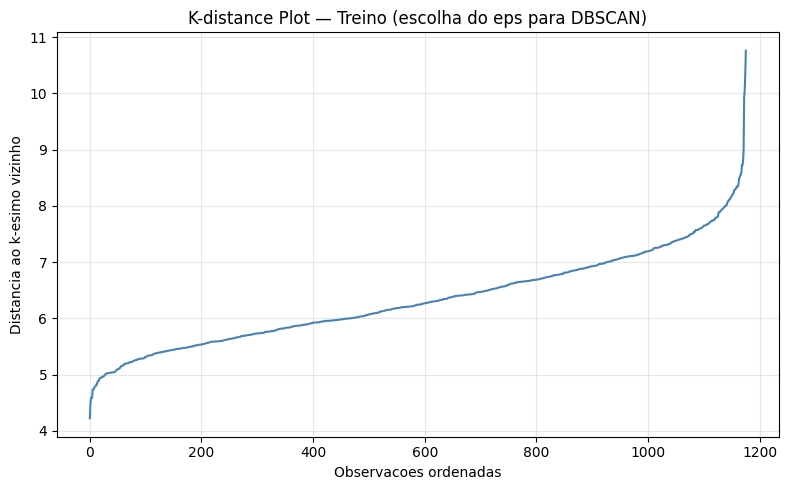

In [15]:
k_nn         = 5
nn           = NearestNeighbors(n_neighbors=k_nn)
nn.fit(X_train_scaled)
distances, _ = nn.kneighbors(X_train_scaled)
distances     = np.sort(distances[:, k_nn - 1])

plt.figure(figsize=(8, 5))
plt.plot(distances, color='steelblue')
plt.title('K-distance Plot — Treino (escolha do eps para DBSCAN)')
plt.xlabel('Observacoes ordenadas')
plt.ylabel('Distancia ao k-esimo vizinho')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('dbscan_kdistance_treino.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.2 Treino do DBSCAN e Métricas

In [16]:
eps_value         = 8.0
dbscan            = DBSCAN(eps=eps_value, min_samples=5)
clusters_train_db = dbscan.fit_predict(X_train_scaled)

n_clusters_db = len(set(clusters_train_db)) - (1 if -1 in clusters_train_db else 0)
noise_train   = np.sum(clusters_train_db == -1)
noise_pct     = noise_train / len(clusters_train_db) * 100

print(f'DBSCAN treino (eps={eps_value}, min_samples=5):')
print(f'  Clusters encontrados: {n_clusters_db}')
print(f'  Ruido:                {noise_train} pontos ({noise_pct:.1f}%)')
print(f'\nDistribuicao clusters treino:')
print(pd.Series(clusters_train_db).value_counts().sort_index().to_string())

mask_train_db = clusters_train_db != -1

if len(set(clusters_train_db[mask_train_db])) > 1:
    sil_train_db = silhouette_score(X_train_scaled[mask_train_db], clusters_train_db[mask_train_db])
    db_train_db  = davies_bouldin_score(X_train_scaled[mask_train_db], clusters_train_db[mask_train_db])
    ch_train_db  = calinski_harabasz_score(X_train_scaled[mask_train_db], clusters_train_db[mask_train_db])
    print(f'\nMetricas TREINO (sem ruido):')
    print(f'  Silhouette Score:       {sil_train_db:.4f}')
    print(f'  Davies-Bouldin Index:   {db_train_db:.4f}')
    print(f'  Calinski-Harabasz:      {ch_train_db:.2f}')
else:
    print('\nClusters insuficientes para calcular metricas.')
    sil_train_db = db_train_db = ch_train_db = float('nan')

DBSCAN treino (eps=8.0, min_samples=5):
  Clusters encontrados: 3
  Ruido:                10 pontos (0.9%)

Distribuicao clusters treino:
-1      10
 0    1125
 1      23
 2      18

Metricas TREINO (sem ruido):
  Silhouette Score:       0.1761
  Davies-Bouldin Index:   1.5601
  Calinski-Harabasz:      34.61


### 7.3 Aplicação ao Teste via KNN

In [17]:
knn_db           = KNeighborsClassifier(n_neighbors=5)
knn_db.fit(X_train_scaled[mask_train_db], clusters_train_db[mask_train_db])
clusters_test_db = knn_db.predict(X_test_scaled)

print('Distribuicao clusters teste (via KNN):')
print(pd.Series(clusters_test_db).value_counts().sort_index().to_string())

if len(set(clusters_test_db)) > 1:
    sil_test_db = silhouette_score(X_test_scaled, clusters_test_db)
    db_test_db  = davies_bouldin_score(X_test_scaled, clusters_test_db)
    ch_test_db  = calinski_harabasz_score(X_test_scaled, clusters_test_db)
else:
    sil_test_db = db_test_db = ch_test_db = float('nan')

print(f'\n===== DBSCAN — TREINO vs. TESTE =====')
print(f'{"Metrica":<25} {"Treino":>10} {"Teste":>10} {"Diferenca":>12}')
print(f'{"-"*57}')
print(f'{"Silhouette Score":<25} {sil_train_db:>10.4f} {sil_test_db:>10.4f} {abs(sil_train_db-sil_test_db):>12.4f}')
print(f'{"Davies-Bouldin":<25} {db_train_db:>10.4f} {db_test_db:>10.4f} {abs(db_train_db-db_test_db):>12.4f}')
print(f'{"Calinski-Harabasz":<25} {ch_train_db:>10.2f} {ch_test_db:>10.2f} {abs(ch_train_db-ch_test_db):>12.2f}')
print(f'\n  Nota: Teste via KNN (DBSCAN nao tem .predict() nativo)')
print(f'  Ruido no treino: {noise_pct:.1f}%  |  Ruido no teste: 0.0% (KNN)')

Distribuicao clusters teste (via KNN):
0    282
1      8
2      4

===== DBSCAN — TREINO vs. TESTE =====
Metrica                       Treino      Teste    Diferenca
---------------------------------------------------------
Silhouette Score              0.1761     0.1719       0.0042
Davies-Bouldin                1.5601     1.5244       0.0357
Calinski-Harabasz              34.61       8.90        25.71

  Nota: Teste via KNN (DBSCAN nao tem .predict() nativo)
  Ruido no treino: 0.9%  |  Ruido no teste: 0.0% (KNN)


### 7.4 Silhouette Plot — DBSCAN (Treino, sem ruído)

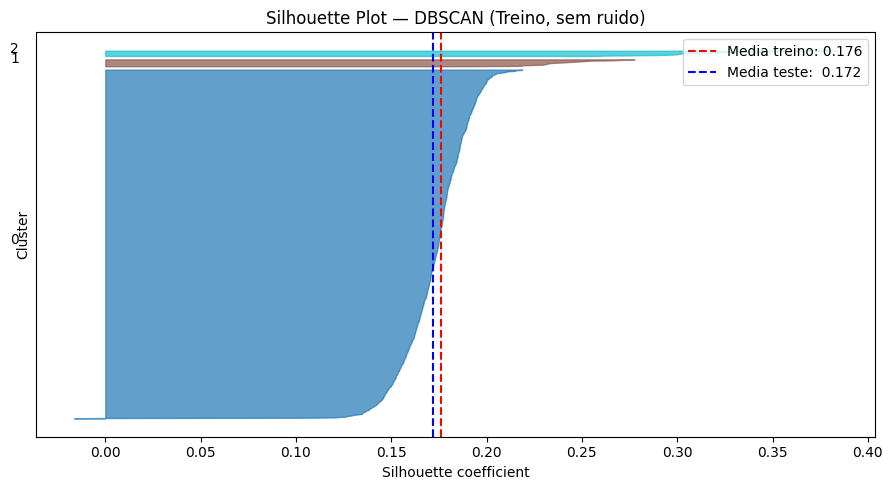

In [18]:
clusters_db_clean = clusters_train_db[mask_train_db]
X_db_clean        = X_train_scaled[mask_train_db]
sample_sil_db     = silhouette_samples(X_db_clean, clusters_db_clean)
unique_db         = sorted(set(clusters_db_clean))

fig, ax = plt.subplots(figsize=(9, 5))
y_lower   = 10
colors_d  = plt.cm.tab10(np.linspace(0, 1, len(unique_db)))

for idx, i in enumerate(unique_db):
    vals    = sample_sil_db[clusters_db_clean == i]
    vals.sort()
    size    = vals.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     facecolor=colors_d[idx], edgecolor=colors_d[idx], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=10)
    y_lower = y_upper + 10

ax.axvline(sil_train_db, color='red',  linestyle='--', linewidth=1.5, label=f'Media treino: {sil_train_db:.3f}')
ax.axvline(sil_test_db,  color='blue', linestyle='--', linewidth=1.5, label=f'Media teste:  {sil_test_db:.3f}')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_title('Silhouette Plot — DBSCAN (Treino, sem ruido)')
ax.set_yticks([])
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('silhouette_plot_dbscan.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.5 Visualização PCA — DBSCAN Treino vs. Teste

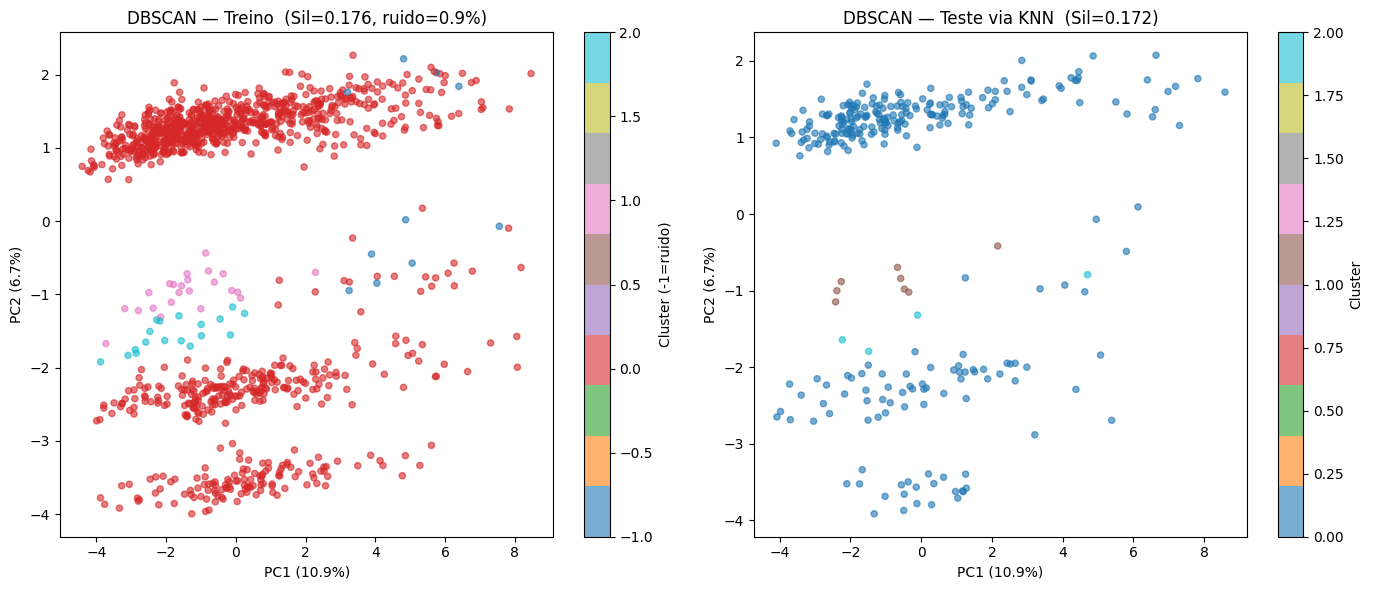

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc1 = axes[0].scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                      c=clusters_train_db, cmap='tab10', alpha=0.6, s=20)
axes[0].set_title(f'DBSCAN — Treino  (Sil={sil_train_db:.3f}, ruido={noise_pct:.1f}%)')
axes[0].set_xlabel(f'PC1 ({variancia[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({variancia[1]*100:.1f}%)')
plt.colorbar(sc1, ax=axes[0], label='Cluster (-1=ruido)')

sc2 = axes[1].scatter(X_test_pca[:, 0], X_test_pca[:, 1],
                      c=clusters_test_db, cmap='tab10', alpha=0.6, s=20)
axes[1].set_title(f'DBSCAN — Teste via KNN  (Sil={sil_test_db:.3f})')
axes[1].set_xlabel(f'PC1 ({variancia[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({variancia[1]*100:.1f}%)')
plt.colorbar(sc2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.savefig('pca_dbscan_treino_teste.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.6 Distribuição dos Clusters — DBSCAN Treino vs. Teste

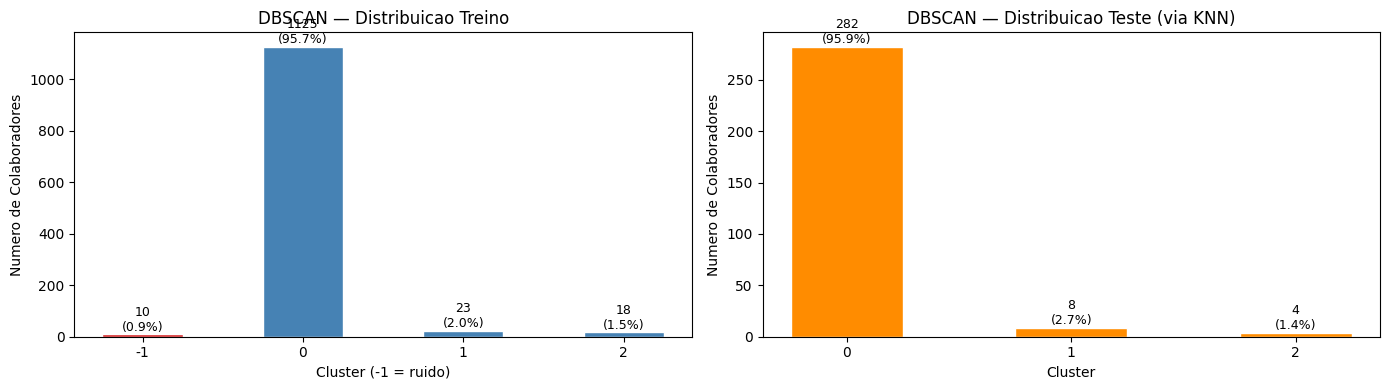

In [20]:
contagem_db_train = pd.Series(clusters_train_db).value_counts().sort_index()
contagem_db_test  = pd.Series(clusters_test_db).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors_dist = ['#d62728' if idx == -1 else 'steelblue'
               for idx in contagem_db_train.index]
bars1 = axes[0].bar(range(len(contagem_db_train)), contagem_db_train.values,
                    color=colors_dist, edgecolor='white', width=0.5)
for bar, val, lbl in zip(bars1, contagem_db_train.values, contagem_db_train.index):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{val}\n({val/len(clusters_train_db)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9)
axes[0].set_xlabel('Cluster (-1 = ruido)')
axes[0].set_ylabel('Numero de Colaboradores')
axes[0].set_title('DBSCAN — Distribuicao Treino')
axes[0].set_xticks(range(len(contagem_db_train)))
axes[0].set_xticklabels(contagem_db_train.index)

bars2 = axes[1].bar(contagem_db_test.index, contagem_db_test.values,
                    color='darkorange', edgecolor='white', width=0.5)
for bar, val in zip(bars2, contagem_db_test.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val}\n({val/len(clusters_test_db)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Numero de Colaboradores')
axes[1].set_title('DBSCAN — Distribuicao Teste (via KNN)')
axes[1].set_xticks(contagem_db_test.index)

plt.tight_layout()
plt.savefig('distribuicao_dbscan_treino_teste.png', dpi=150, bbox_inches='tight')
plt.show()